In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [9]:
file_path = "../outputs/"

# Analysis Excercise 02.1

### Montecarlo estimation of an integral: uniform and importance sampling

In this excercise we aim to evaluate an integral

$$I = \int_a^b f(x) dx$$

via Monte Carlo methods.

The estimator for the integral is the quantity

$$(b-a)\langle g \rangle = (b-a)\frac{1}{N}\sum_{i=1}^Ng(x_i)$$

where the $x_i$ are extracted from a distribution $p(x)$, such that $g(x)p(x)=f(x)$, and $N$ is the number of variables extracted. The Central Limit Theorem assures that the estimator converges to the true value of the integral.

In general every $p(x)$ is suitable for the calculation of the integral, but not equivalently efficient: the more the probability distribution is similar to the integrand function, the smaller is the error on the estimation of the integral at fixed $N$. In general the best $p(x)$ would be the normalized module of the integrand, that would imply knowing the value of the integral, which is exactly what we aim to obtain. The strategy is, therefore, to find a probability distribution $d(x)$ that resembles the integrand function and refactor the integal like


$$I = \int_a^b \frac{g(x)p(x)}{d(x)}d(x) dx$$

and extract the $x_i$ according to the distribution $d(x)$ evaluating the function $h(x)=\frac{g(x)p(x)}{d(x)}$.

The evaluation method based on the sampling according to a distribution similar to the integrand will be referred to as $\textit{importance sampling}$ in the following.

For this exercise the integral to evaluate is

$$I = \int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right) dx$$

### Uniform sampling

At first I evaluated the integral sampling the $x_i$ from a uniform density distribution, evaluating the integrand $\frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right)$ in the extracted points.

### Importance sampling

To implement the importance sampling method, I decided to use the normalised first order Taylor expansion of the integrand around $x=1$. Taking a look at the derivatives of the integrand function

$$f^{\prime}(x) = -\frac{\pi^2}{4} \sin\left(\frac{\pi}{2}x\right)$$
$$f^{\prime\prime} = -\frac{\pi^3}{8} \cos\left(\frac{\pi}{2}x\right)$$

one notices that expanding around $x=0$ the Taylor expansion to the first non zero order of the integrand would be

$$d(x) = \mathcal{N} \left(\frac{\pi}{2} - \frac{\pi^3}{16}x^2\right)$$

where $\mathcal{N}$ is the normalization constant for $d(x)$ should be a probability distribution: this choice holds a problem, that is that for $x=1$ $d(x)$ is negative, therefore it is not a good probability distribution for the solution of our problem.

The choice of expanding around $x=1$ gives a normalized probability distribution

$$d(x) = 2(1-x)\chi_{[0,1]}$$
which is positive for all values $x \in [0, 1]$. The function to evaluate is

$$h(x) = \frac{\pi}{4}\frac{\cos\left(\frac{\pi}{2}x\right)}{1-x}$$

In order to extract values according to the distribution $d(x)$ I chose to use the inverse transform method. The cumulative function is

$$D(x) = \int_0^x 2(1-x^{\prime}) dx^{\prime} = 2\left(x-\frac{x^2}{2}\right)$$

which is not globally invertible, but can be inverted locally in the interval $[0, 1]$. The inversion gives the law

$$x(r) = 1-\sqrt{1-r}$$

where $r$ is a number uniformly distributed in $[0, 1)$. 

In the plot below one can see that the distribution of the number extracted with this method is the expected one.

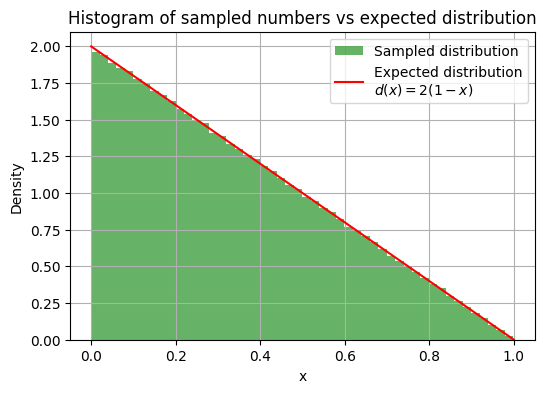

In [24]:
np.random.seed(42)
random_numbers = np.random.uniform(0, 1, size=1000000)

x = 1-np.sqrt(1-random_numbers)

plt.figure(figsize=(6, 4))

# density=True to normalize the histogram and compare it with the expected distribution
plt.hist(x, bins=50, density=True, alpha=0.6, color='g', label='Sampled distribution') 

plt.plot(np.linspace(0, 1, 100), 2*(1-np.linspace(0, 1, 100)), 'r-', label='Expected distribution\n$d(x) = 2(1-x)$')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram of sampled numbers vs expected distribution')
plt.legend()
plt.grid(True)
plt.show()

The expected result is that the evaluation with the importance sampling reduces the variance on the value on the integral, and therefore leads to a smaller standard deviation with respect to the uniform sampling.

The plot below shows the progressive estimate of the integral with the respective uncertainties versus the progressive number of throws: the importance sampling method gives a visibly and sistematically smaller uncertainty on the estimate of the integral with respect to the uniform sampling method.

In [28]:
# Extract information from the file
throws, estimate_prog_unif, err_prog_unif, estimate_prog_importance, erro_prog_importance = np.loadtxt(file_path + "02_1_integral.dat", unpack=True)

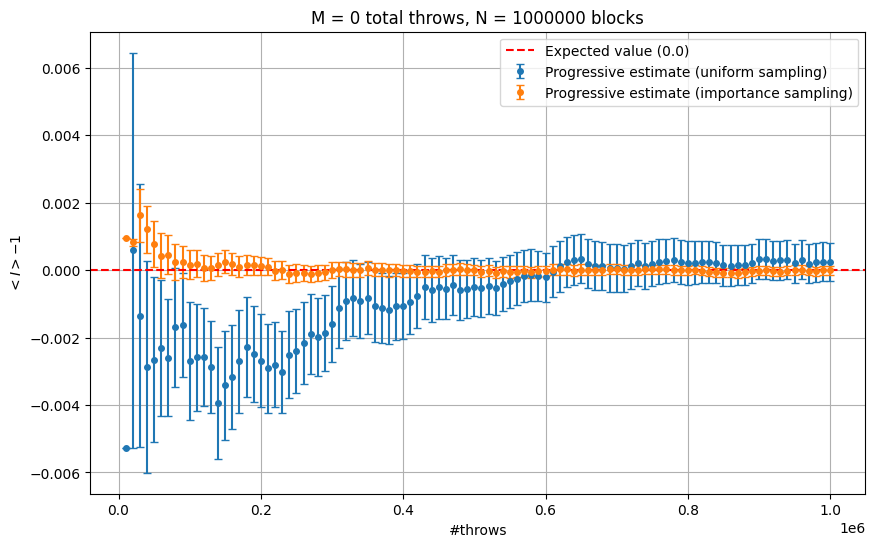

In [29]:
plt.figure(figsize=(10, 6))

plt.errorbar(throws, estimate_prog_unif - 1, yerr=err_prog_unif, label = 'Progressive estimate (uniform sampling)', fmt='o', markersize=4, capsize=3)
plt.errorbar(throws, estimate_prog_importance - 1, yerr=erro_prog_importance, label = 'Progressive estimate (importance sampling)', fmt='o', markersize=4, capsize=3)
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('#throws')
plt.ylabel('$<I> - 1$')
plt.title('M = {} total throws, N = {} blocks'.format(int(x[-1]), int(len(x))))
plt.grid(True)
plt.legend()
plt.show()

In [30]:
mean_final_estimate_unif = estimate_prog_unif[-1]
mean_final_error_unif = err_prog_unif[-1]
print(f"===== Final estimation of the integral (uniform sampling): {mean_final_estimate_unif:.4f} ± {mean_final_error_unif:.4f} =====")

mean_final_estimate_importance = estimate_prog_importance[-1]
mean_final_error_importance = erro_prog_importance[-1]
print(f"===== Final estimation of the integral (importance sampling): {mean_final_estimate_importance:.4f} ± {mean_final_error_importance:.4f} =====")

===== Final estimation of the integral (uniform sampling): 1.0002 ± 0.0006 =====
===== Final estimation of the integral (importance sampling): 1.0000 ± 0.0001 =====


# Analysis Excercise 02.2

In the following exercise we aim to analyze the dependence of the mean squared root of a $3D$ Random Walk (RW) process $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ with the number of steps $N$. We analyze this dependence first with a RW defined on a cubic lattice and then on one with spherical symmetry. This quantity represents the average length that the random walker covers in a fixed number of steps $N$.

A RW is a stochastic process in whic a walker, a point in the $d$ - dimensional space, moves in the space. In this case we consider a discrete time RW with fixed step length $a=1$. The important property of a RW is that it is a Markovian Process: the probability for the walker to be in a point $x_t$ at a time $t$ only depends on the position $x_{t-1}$ at time $t-1$ and not on the rest of the history of the walker.

In this exercise we consider the case of the directions being all equally probable: this defines a $\textit{Universlity Class}$. The universality is given by the fact that if one evaluates the root mean squared displacement after $N$ steps, one finds a dependence

$$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}} = a\sqrt{N}$$

regardless of the dimension of the problem or the symmetry of the space (discrete of spherically continuous)

In the cubic lattice the walker can move one step at a time along one of three orthogonal directions forward ($+1$) or backwards ($-1$). In the spherical space at each step the walker decider an angle that is uniformly distributed on the unit sphere and makes a step on length $a=1$ in that direction.

In the exercise I stored the sum of the squared norm of the position at each step in a vector and at the end of each block I calculate the square root of the mean of each element of that vector. I store all the progressive means over all the blocks in another vector and then print that vector to file (repeat for both cubic lattice and spherical symmetry), and I calculate the uncertainty with the data blocking method.

What I obtain is a curve of the root mean squared for both random walks with the respective uncertainties, as function of the number of steps $N$.

In the following two graphs I represent the curve fitted to the function $$f(N) = k\sqrt{N}$$ where $k$ is the constant obtained from the fit (since the relation $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}} = a\sqrt{N}$ holds, we expect $k$ to be close to the value of $a$).


In [47]:
# Extract information from file
step, rw_lattice, err_lattice, rw_cont, err_cont = np.loadtxt(file_path + "02_2_RW.dat", unpack=True)

In [48]:
# Define the function to fit (f(N) = k * sqrt(N))
def fit_func(x, k):
    return k * np.sqrt(x)

# Perform the fit an extract the parameters
# lattice
params_lat, _ = curve_fit(fit_func, x, rw_lattice)
k_lat = params_lat[0]

# continuous
params_cont, _ = curve_fit(fit_func, x, rw_cont)
k_cont = params_cont[0]

### Plot lattice

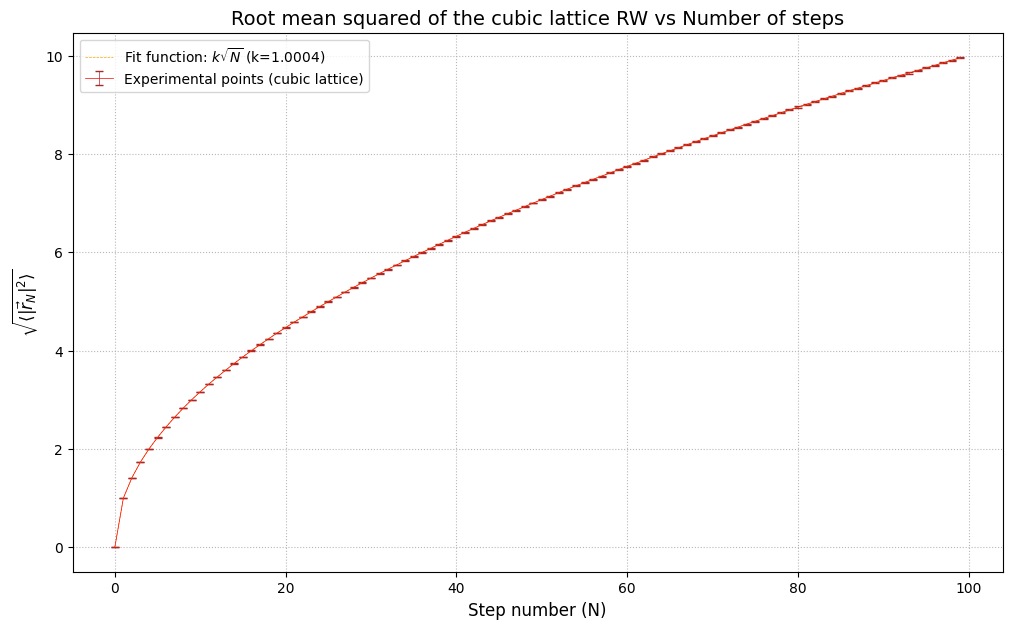

In [49]:
plt.figure(figsize=(12, 7))

plt.errorbar(step, rw_lattice, yerr=err_lattice, label='Experimental points (cubic lattice)', color='red', linewidth=0.5, ecolor='brown', capsize=3)
plt.plot(step, fit_func(step, k_lat), color='orange', linestyle='--', linewidth=0.5, label=f'Fit function: $k\\sqrt{{N}}$ (k={k_lat:.4f})')

# Personalizzazione del grafico
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle}$', fontsize=12)
plt.title('Root mean squared of the cubic lattice RW vs Number of steps', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)

### Plot continuous

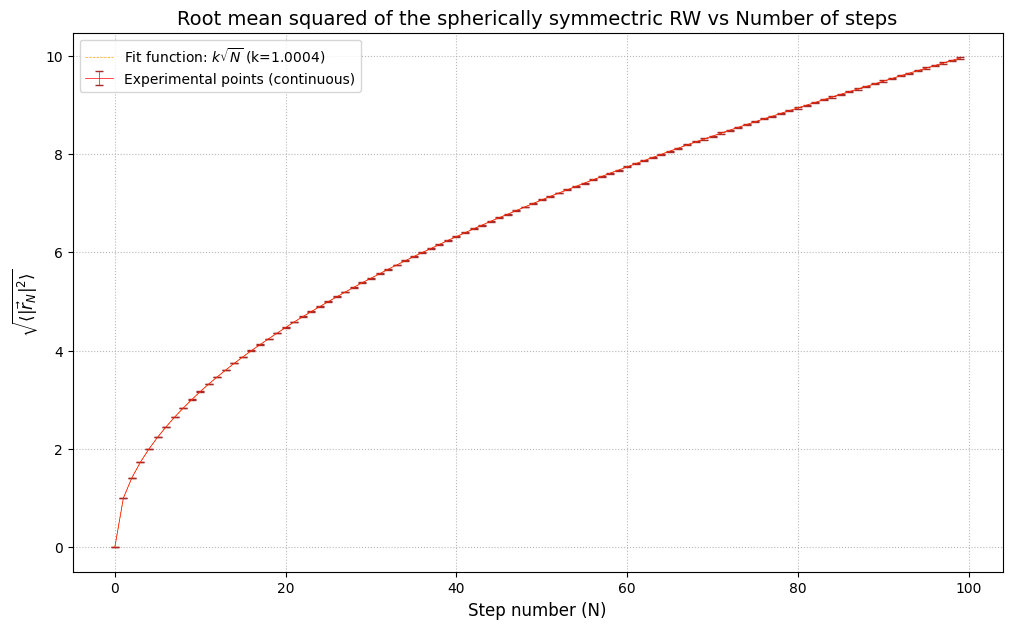

In [50]:
plt.figure(figsize=(12, 7))

plt.errorbar(step, rw_cont, yerr=err_cont, label='Experimental points (continuous)', color='red', linewidth=0.5, ecolor='brown', capsize=3)
plt.plot(step, fit_func(step, k_cont), color='orange', linestyle='--', linewidth=0.5, label=f'Fit function: $k\\sqrt{{N}}$ (k={k_lat:.4f})')

# Personalizzazione del grafico
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle}$', fontsize=12)
plt.title('Root mean squared of the spherically symmectric RW vs Number of steps', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)

### Visible error bars

As one can see, the experimental points are practically superimposed on the theoretical curve and the error bars are too small to be appreciated.

Therefore in the following I plot the difference between the experimental points and the theoretical values: one can see that the values oscillate around zero with fluctuations compatible with the error bars, here clearly visible.

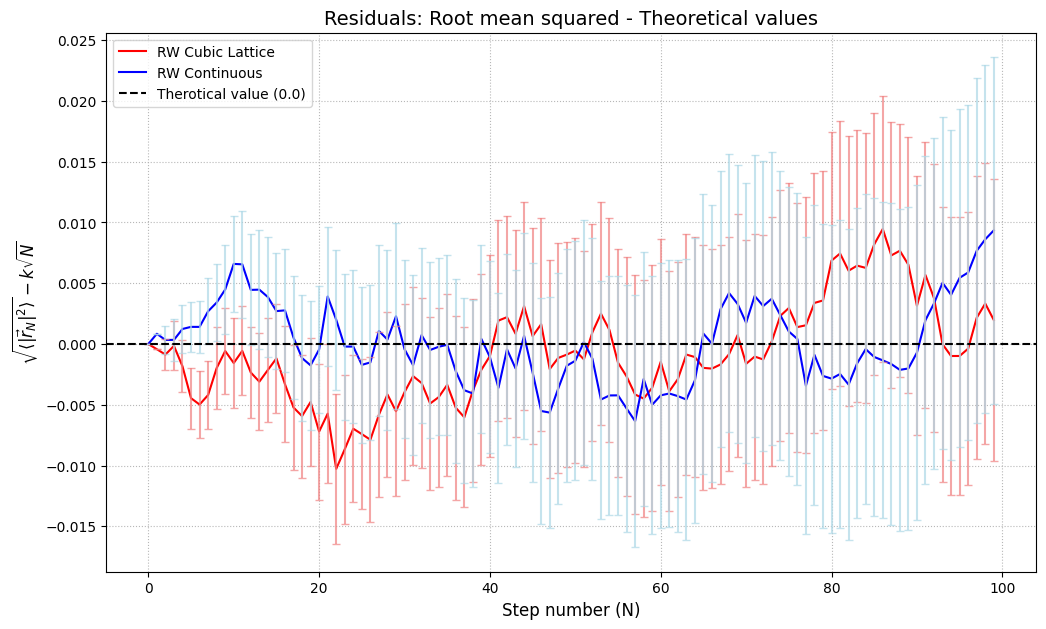

In [62]:
plt.figure(figsize=(12, 7))

plt.plot(x, rw_lattice - fit_func(x, k_lat), c='red', label='RW Cubic Lattice')
plt.plot(x, rw_cont - fit_func(x, k_cont), c='blue', label='RW Continuous')

plt.errorbar(x, rw_lattice - fit_func(x, k_lat), yerr=err_lattice, fmt='none', ecolor='lightcoral', capsize=3, alpha=0.7)
plt.errorbar(x, rw_cont - fit_func(x, k_cont), yerr=err_cont, fmt='none', ecolor='lightblue', capsize=3, alpha=0.7)


plt.axhline(0, color='black', linestyle='--', label='Therotical value (0.0)')
plt.xlabel('Step number (N)', fontsize=12)
plt.ylabel(r'$\sqrt{\langle |\vec{r}_N|^2 \rangle} - k\sqrt{N}$', fontsize=12)
plt.title('Residuals: Root mean squared - Theoretical values', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.9)
plt.show()